<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment2/%20Assignment%202%3A%20The%20Algorithmic%20Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Manual DGP Simulation
normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)
latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [ ]:
def calculate_mad(data):
  # 1. Calculate the Median of the data
  median = np.median(data)
  # 2. Calculate Absolute Deviations (|x - median|)
  abs_deviations = np.abs(data - median)
  # 3. Return the Median of those deviations
  mad = np.median(abs_deviations)
  return mad

# 4. Let's compare it with the SD
stdev = np.std(latency_logs)
mad = calculate_mad(latency_logs)

print(f"Standard Deviation:{stdev:.2f}")
print(f"Median Absolute Deviation (MAD):{mad:.2f}")

Standard Deviation:422.17
Median Absolute Deviation (MAD):8.00


The standard deviation uses squared deviations from the mean, so outliers contribute much more to the SD. In the MAD, absolute deviations are used, so the original deviations are not scaled as much. Outliers only contribute in absolute value, and since the MAD takes the median here, these values do not pull the true representative MAD very far in any direction.

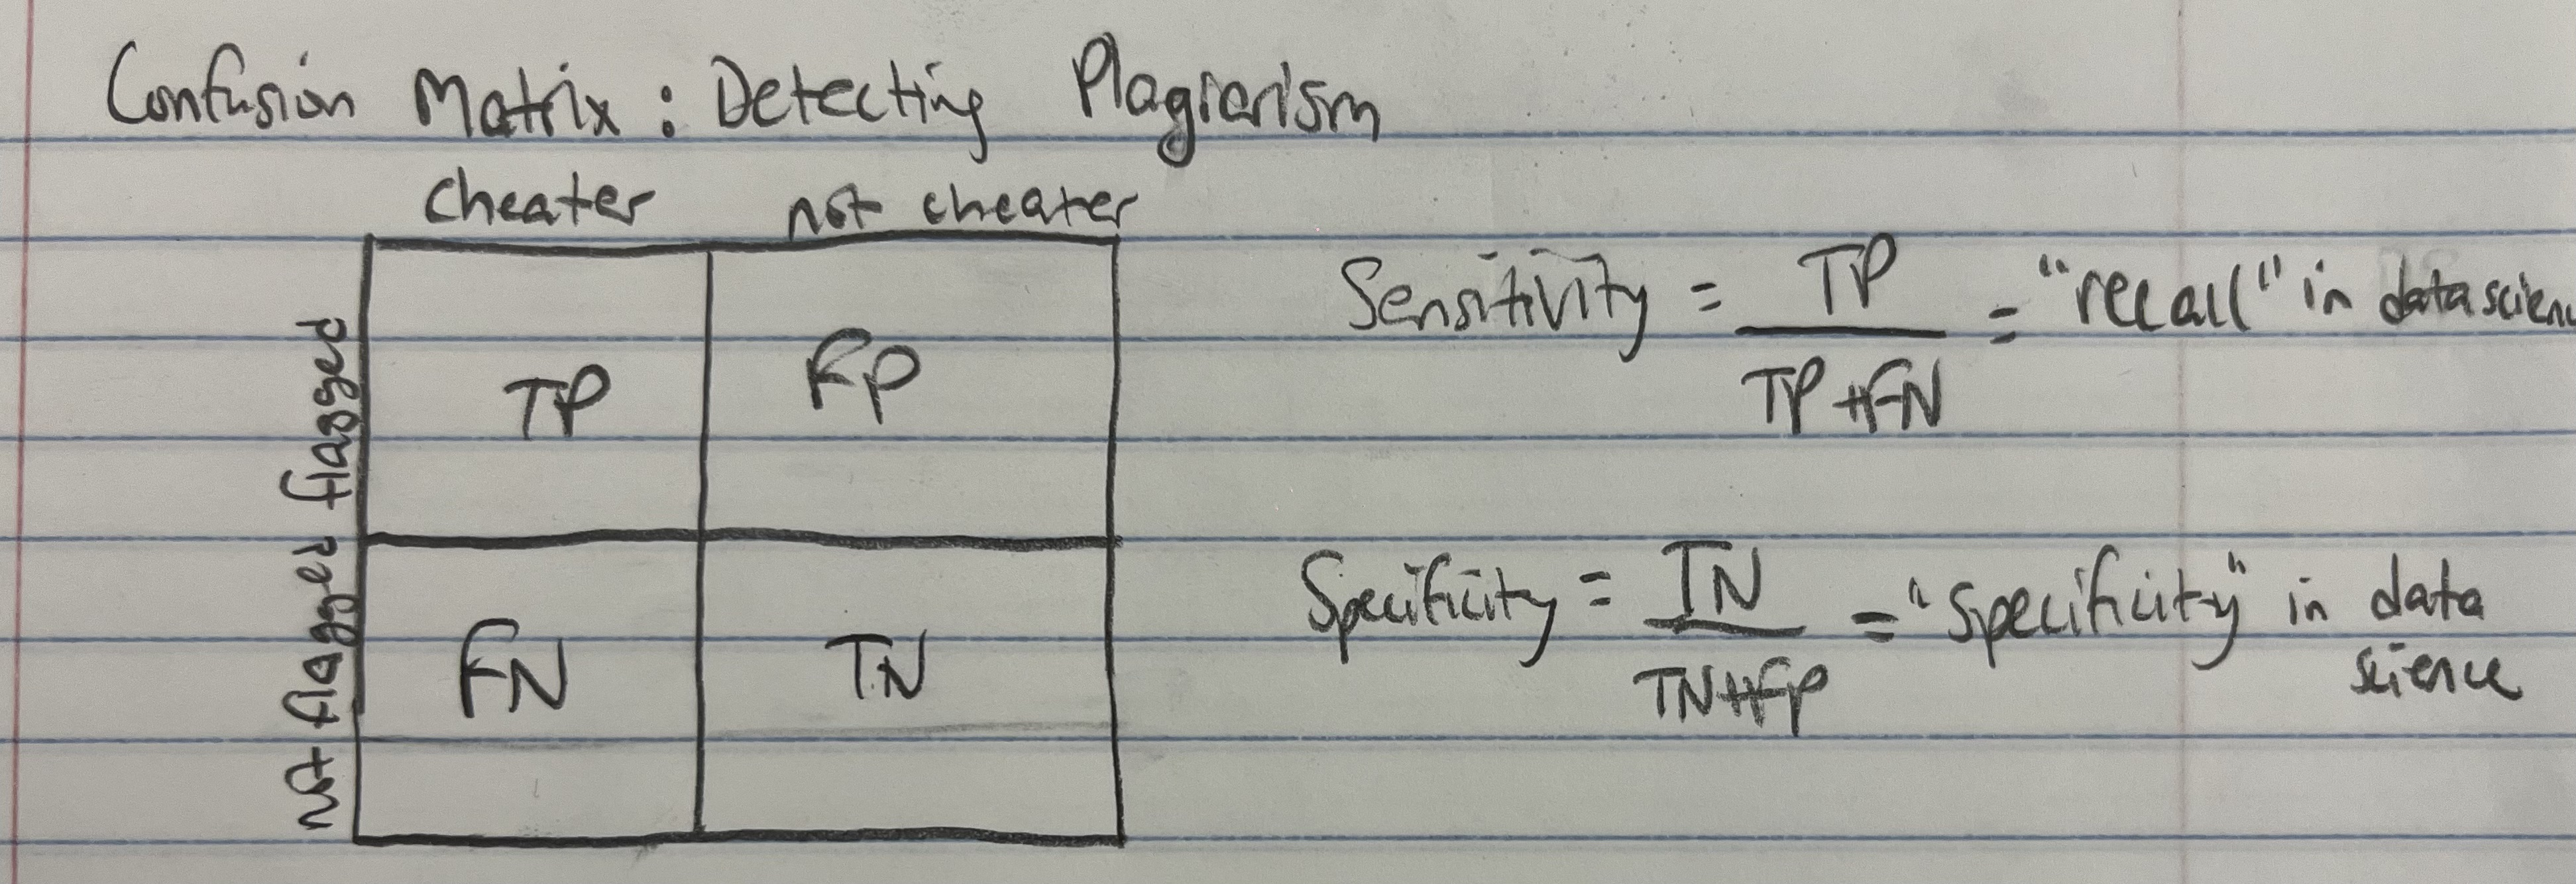

In [ ]:
def bayesian_audit(prior, sensitivity, specificity):
    # P(Flagged | Cheater) = sensitivity
    # P(Not Flagged | Not Cheater) = specificity
    # P(Flagged | Not Cheater) = 1 - specificity

    # P(Flagged and Cheater) = P(Flagged | Cheater) * P(Cheater)
    p_flagged_and_cheater = sensitivity * prior

    # P(Flagged and Not Cheater) = P(Flagged | Not Cheater) * P(Not Cheater)
    p_flagged_and_not_cheater = (1 - specificity) * (1 - prior)

    # P(Flagged) = P(Flagged and Cheater) + P(Flagged and Not Cheater)
    p_flagged = p_flagged_and_cheater + p_flagged_and_not_cheater

    # P(Cheater | Flagged) = P(Flagged and Cheater) / P(Flagged)
    posterior = p_flagged_and_cheater / p_flagged

    return posterior

# test the scenarios using the function
sensitivity = 0.98
specificity = 0.98

scenario_a = bayesian_audit(0.50, sensitivity, specificity)
scenario_b = bayesian_audit(0.05, sensitivity, specificity)
scenario_c = bayesian_audit(0.001, sensitivity, specificity)

print(f"Scenario A (Bootcamp, 50%): {scenario_a:.4f}")
print(f"Scenario B (Econ Class, 5%): {scenario_b:.4f}")
print(f"Scenario C (Honors Seminar, 0.1%): {scenario_c:.4f}")


Scenario A (Bootcamp, 50%): 0.9800
Scenario B (Econ Class, 5%): 0.7206
Scenario C (Honors Seminar, 0.1%): 0.0468


In [12]:
# Chi-Square Formula: Sum( (Observed - Expected)^2 / Expected )
observed = np.array([50250, 49750])
expected = np.array([50000, 50000])
# Write the calculation loop...
chi_sq = 0
for i in range(len(observed)):
  chi_sq += (observed[i] - expected[i]) ** 2 / expected[i]

print(f"Observed: {observed}")
print(f"Expected: {expected}")
print(f"Chi-Squared Statistic: {chi_sq:.2f}")

if chi_sq > 3.84:
  print("The chi-squared statistic is not statisitcally "
        "significant at the 0.05 level, observed data has "
        "engineering bias from random assignment.")
else:
  print("The chi-squared statistic is statisitcally "
        "significant at the 0.05 level, observed data does not have "
        "bias from random assignment.")

Observed: [50250 49750]
Expected: [50000 50000]
Chi-Squared Statistic: 2.50
The chi-squared statistic is statisitcally significant at the 0.05 level, observed data does not have bias from random assignment.


Total Tokens: 10000
Survivors (Top 1%): 100

Mean Market Cap (All Tokens): $174,084.21
Mean Market Cap (Survivors Only): $4,363,352.12

Survivorship Bias Multiplier: 25.06x


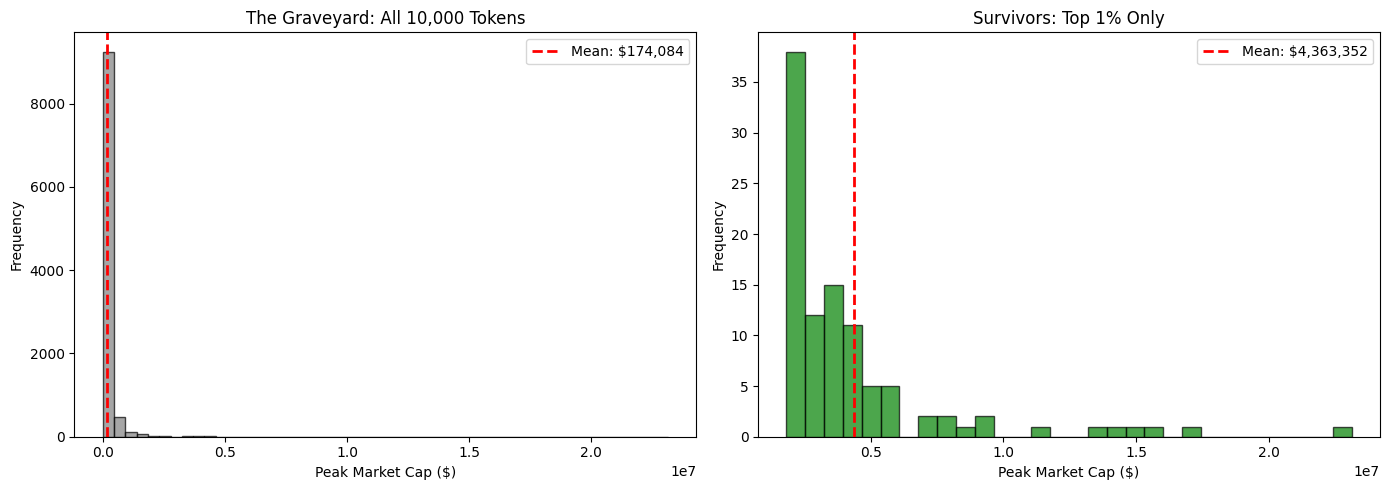

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Simulate 10,000 token launches
np.random.seed(42)
n_tokens = 10000

# Pareto Distribution (Power Law) - shape parameter controls inequality
# Lower shape = more extreme inequality (99% near zero)
peak_market_cap = np.random.pareto(a=1.5, size=n_tokens) * 100000

# Create df_all (The Graveyard)
df_all = pd.DataFrame({
    'token_id': range(n_tokens),
    'peak_market_cap': peak_market_cap
})

# Create df_survivors (Top 1% only)
threshold = np.percentile(peak_market_cap, 99)
df_survivors = df_all[df_all['peak_market_cap'] >= threshold].copy()

# Calculate means
mean_all = df_all['peak_market_cap'].mean()
mean_survivors = df_survivors['peak_market_cap'].mean()

# Print results
print(f"Total Tokens: {len(df_all)}")
print(f"Survivors (Top 1%): {len(df_survivors)}")
print(f"\nMean Market Cap (All Tokens): ${mean_all:,.2f}")
print(f"Mean Market Cap (Survivors Only): ${mean_survivors:,.2f}")
print(f"\nSurvivorship Bias Multiplier: {mean_survivors/mean_all:.2f}x")

# Dual histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All tokens
axes[0].hist(df_all['peak_market_cap'], bins=50, edgecolor='black', alpha=0.7, color='gray')
axes[0].axvline(mean_all, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_all:,.0f}')
axes[0].set_xlabel('Peak Market Cap ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('The Graveyard: All 10,000 Tokens')
axes[0].legend()

# Survivors only
axes[1].hist(df_survivors['peak_market_cap'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(mean_survivors, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_survivors:,.0f}')
axes[1].set_xlabel('Peak Market Cap ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Survivors: Top 1% Only')
axes[1].legend()

plt.tight_layout()
plt.show()